# Parte 3: Modelo A vs. Modelo B (Auditoria e Recomendação)

---

## Objetivos da Análise

Esta fase final tem o objetivo de determinar, com rigor estatístico, se a substituição do classificador atual (Modelo A) pelo candidato (Modelo B) traz ganho real para a operação da Central 1746. 

A literatura de avaliação de modelos alerta para o risco de avaliar trocas de sistemas baseando-se apenas em médias globais. Modelos podem apresentar ganhos aparentes ao sacrificar a precisão em categorias minoritárias críticas. Portanto, nossa análise segue o método top-down:
1. **Visão Macro:** Comparação global de métricas (F1-Score, Acurácia, Precision e Recall).
2. **Validação Estatística (Teste de McNemar):** Avaliação de significância matemática da diferença de erros entre os modelos (amostras pareadas).
3. **Visão Micro (Trade-offs):** Análise de ganhos e perdas de F1-Score por categoria.
4. **Resolução de Falhas Logísticas:** Verificação do comportamento do Modelo B na sobreposição estrutural entre `esgoto_vazamento` e `buraco_via`.

---

## Passo 1: Visão Macro (Comparação Global)

O primeiro passo estabelece a premissa fundamental da comparação. Avaliamos as métricas globais agregadas para entender qual modelo possui o melhor desempenho geral. 

**Decisão Metodológica:**
Como comprovado na Fase 1, o dataset apresenta forte desbalanceamento. Por esse motivo, a **Acurácia** será calculada apenas como métrica de controle, enquanto o **F1-Score (Macro)** será o norteador da decisão de performance geral, garantindo que o acerto nas classes minoritárias possua o mesmo peso da classe majoritária na avaliação agregada.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pathlib import Path

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Carregamento dos dados
DATA_PATH = Path("../dados/chamados_com_predicoes.csv")
np.random.seed(42)

In [2]:
df = pd.read_csv(DATA_PATH)

y_true = df['categoria_real'].values
y_pred_a = df['pred_modelo_a'].values
y_pred_b = df['pred_modelo_b'].values

def calcular_metricas_globais(y_true, y_pred, nome_modelo):
    return {
        'Modelo': nome_modelo,
        'Acurácia': accuracy_score(y_true, y_pred),
        'Precision (Macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

# Tabela Comparativa
metricas_a = calcular_metricas_globais(y_true, y_pred_a, 'Modelo A (Produção)')
metricas_b = calcular_metricas_globais(y_true, y_pred_b, 'Modelo B (Candidato)')
df_comparacao = pd.DataFrame([metricas_a, metricas_b]).set_index('Modelo')
df_comparacao.loc['Delta (B - A)'] = df_comparacao.loc['Modelo B (Candidato)'] - df_comparacao.loc['Modelo A (Produção)']

print("=== Comparação Global de Desempenho ===")
display(df_comparacao.round(4))

=== Comparação Global de Desempenho ===


,Acurácia,Precision (Macro),Recall (Macro),F1-Score (Macro)
Modelo,,,,
Modelo A (Produção),0.7728,0.7743,0.7710,0.7704
Modelo B (Candidato),0.8676,0.8596,0.8523,0.8516
Delta (B - A),0.0948,0.0853,0.0813,0.0811


### Resultados

Os resultados agregados indicam uma aparente superioridade do Modelo B, que obteve um ganho absoluto de aproximadamente 8,11 pontos percentuais no F1-Score Macro e 9,48 pontos na Acurácia. 

No entanto, antes de declarar o Modelo B como vencedor, precisamos responder a duas perguntas na auditoria de modelos:
1. Esse ganho global é matematicamente real ou apenas uma variação amostral (ruído)?
2. O ganho global esconde perdas críticas no nível micro (trade-offs em categorias específicas)?

---

## Passo 2: Validação Estatística (Teste de McNemar)

Para garantir que a diferença de performance não é obra do acaso, aplicamos um teste de hipótese estatística. 

**Decisão Metodológica:**
Como as previsões do Modelo A e do Modelo B foram geradas sobre o mesmo conjunto de 5.000 chamados, estamos lidando com amostras dependentes (pareadas). O uso de testes tradicionais como o Qui-Quadrado de Pearson comum é inválido aqui, pois pressupõe amostras independentes. O teste correto para comparação de algoritmos de classificação neste desenho amostral é o Teste de McNemar

O Teste de McNemar foca exclusivamente nas discordâncias entre os modelos (casos onde A errou e B acertou, ou vice-versa).
* **Hipótese Nula ($H_0$):** A proporção de erros dos dois modelos é igual (desempenho equivalente).
* **Critério:** Se o $p\text{-valor} < 0.05$, rejeitamos $H_0$ e confirmamos que a superioridade de um dos modelos é estatisticamente significante.

In [3]:
from statsmodels.stats.contingency_tables import mcnemar

# Acertos e Erros (Binarização)
acertou_a = (y_true == y_pred_a)
acertou_b = (y_true == y_pred_b)

# Matriz de Contingência 2x2
# Linhas: Modelo A (Acertou, Errou)
# Colunas: Modelo B (Acertou, Errou)
ambos_acertaram = np.sum(acertou_a & acertou_b)
a_acertou_b_errou = np.sum(acertou_a & ~acertou_b)
a_errou_b_acertou = np.sum(~acertou_a & acertou_b)
ambos_erraram = np.sum(~acertou_a & ~acertou_b)

matriz_mcnemar = [
    [ambos_acertaram, a_acertou_b_errou],
    [a_errou_b_acertou, ambos_erraram]
]

df_contingencia = pd.DataFrame(
    matriz_mcnemar,
    columns=['Modelo B Acertou', 'Modelo B Errou'],
    index=['Modelo A Acertou', 'Modelo A Errou']
)

print("=== Matriz de Contingência (Acertos Cruzados) ===")
display(df_contingencia)

# Usamos exact=False para aproximação qui-quadrado (ok pois N >>> 25)
resultado_mcnemar = mcnemar(matriz_mcnemar, exact=False)

print(f"\n=== Resultado do Teste de McNemar ===")
print(f"Estatística do Teste (Qui-Quadrado): {resultado_mcnemar.statistic:.4f}")
print(f"p-valor: {resultado_mcnemar.pvalue:.4e}")

=== Matriz de Contingência (Acertos Cruzados) ===


,Modelo B Acertou,Modelo B Errou
Modelo A Acertou,3347,517
Modelo A Errou,991,145



=== Resultado do Teste de McNemar ===
Estatística do Teste (Qui-Quadrado): 148.3614
p-valor: 3.9549e-34


### 2.1. Conclusão da Validação Estatística

A estatística de teste e o p-valor de $3.95 \times 10^{-34}$ (muito inferior ao limiar de 0.05) fornecem evidência matemática conclusiva para rejeitar a hipótese nula. A superioridade de 8.11 pontos de F1-Score do Modelo B não é um artefato de variação amostral. Trata-se de um ganho preditivo estrutural na distinção dos chamados.

---

## Passo 3: Visão Micro (Análise de Trade-offs por Categoria)

Em auditorias de modelos aplicados a políticas públicas, um ganho global estatisticamente significante não justifica, por si só, a substituição de um sistema. Modelos focados em otimização de métricas globais frequentemente desenvolvem *majority class bias*, sacrificando a precisão em categorias de menor volume para aumentar a pontuação naquelas mais frequentes.

Para investigar se o Modelo B impõe um "custo oculto" à operação logística da prefeitura, calculamos o Delta do F1-Score (Modelo B - Modelo A* para cada uma das categorias do dataset. O objetivo é identificar visualmente e numericamente se a adoção do Modelo B causa degradação de atendimento em algum serviço específico.

=== Deltas de F1-Score por Categoria ===


,Categoria,F1 Modelo A,F1 Modelo B,Delta (B - A)
6,poda_arvore,0.7889,0.6418,-0.1471
5,iluminacao_publica,0.8236,0.8902,0.0666
4,estacionamento_irregular,0.8131,0.8809,0.0678
0,barulho_perturbacao,0.7878,0.8638,0.0760
2,coleta_lixo,0.8105,0.8985,0.0880
7,sinalizacao,0.7686,0.8694,0.1008
1,buraco_via,0.7328,0.8938,0.1609
3,esgoto_vazamento,0.6382,0.8741,0.2359


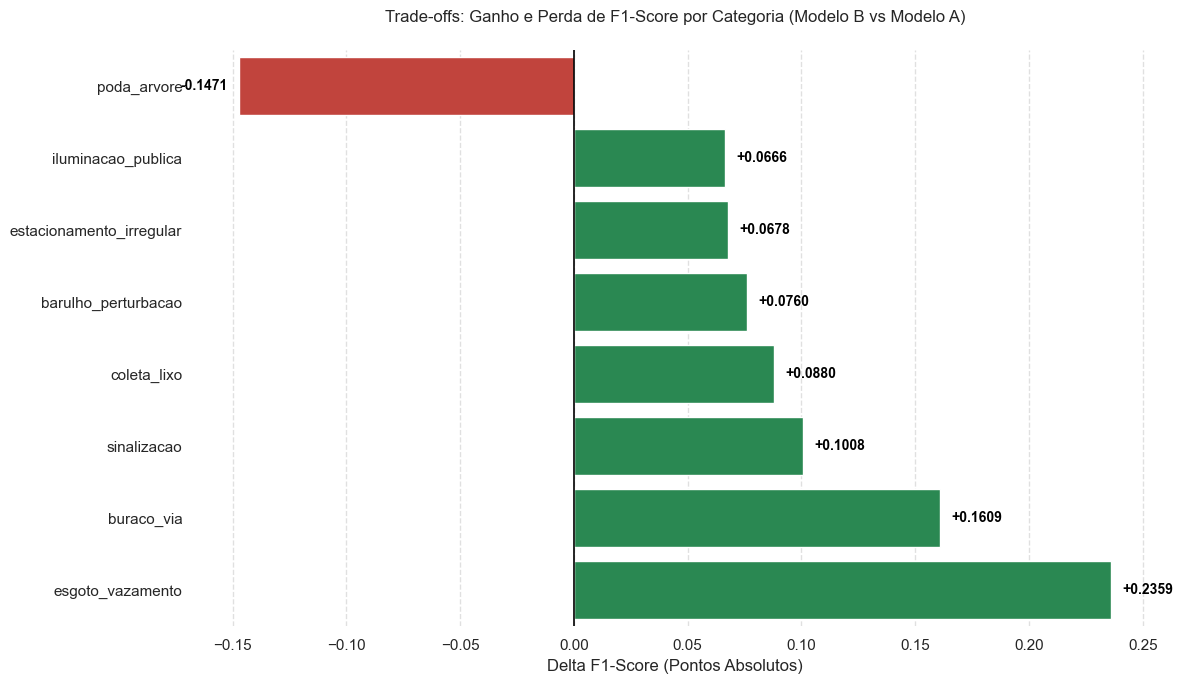

In [4]:
from sklearn.metrics import precision_recall_fscore_support

# F1-Scores por Categoria
classes = np.unique(y_true)
_, _, f1_a, _ = precision_recall_fscore_support(y_true, y_pred_a, labels=classes, zero_division=0)
_, _, f1_b, _ = precision_recall_fscore_support(y_true, y_pred_b, labels=classes, zero_division=0)

df_deltas = pd.DataFrame({
    'Categoria': classes,
    'F1 Modelo A': f1_a,
    'F1 Modelo B': f1_b,
    'Delta (B - A)': f1_b - f1_a
}).sort_values(by='Delta (B - A)', ascending=True)

print("=== Deltas de F1-Score por Categoria ===")
display(df_deltas.round(4))

plt.figure(figsize=(12, 7))
cores = ['#d73027' if x < 0 else '#1a9850' for x in df_deltas['Delta (B - A)']]

ax = sns.barplot(
    x='Delta (B - A)', 
    y='Categoria', 
    data=df_deltas, 
    palette=cores,
    hue='Categoria',
    legend=False
)

# Anotação numérica diretamente nas barras
for i, v in enumerate(df_deltas['Delta (B - A)']):
    ax.text(
        v + (0.005 if v >= 0 else -0.005), 
        i, 
        f"{v:+.4f}", 
        va='center', 
        ha='left' if v >= 0 else 'right',
        color='black',
        fontweight='bold',
        fontsize=10
    )

plt.title('Trade-offs: Ganho e Perda de F1-Score por Categoria (Modelo B vs Modelo A)', pad=20)
plt.xlabel('Delta F1-Score (Pontos Absolutos)')
plt.ylabel('')
plt.axvline(0, color='black', linewidth=1.2)

ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.6)
ax.yaxis.grid(False)

plt.tight_layout()
plt.show()

#### Resultados (Ganhos vs. Perdas)

A análise analítica de deltas ratifica a presença de um *trade-off* estrutural na troca das arquiteturas.

1. **Mitigação do Gargalo Principal:** O Modelo B obteve um salto de performance expressivo justamente nas categorias problemáticas do Modelo A: `esgoto_vazamento` (+0.2359) e `buraco_via` (+0.1609). 
2. **Regressão Crítica:** O ganho global custou uma degradação grande na detecção de `poda_arvore` (-0.1471). A matemática de otimização do Modelo B sacrificou a extração semântica de problemas de arborização urbana.

---

## Passo 4: Auditoria Visual da Resolução e Vazamento (Matriz B)

A literatura de avaliação de classificadores multiclasse orienta a inspeção direta da matriz de confusão concorrente para confirmar se um erro de sobreposição semântica foi resolvido ou se os falsos positivos foram meramente transferidos para uma terceira classe.

O objetivo desta visualização é:
1. Comprovar a eliminação do roteamento incorreto entre saneamento (`esgoto_vazamento`) e pavimentação (`buraco_via`).
2. Rastrear o destino dos falsos negativos de `poda_arvore` (para onde o Modelo B está enviando equivocadamente os chamados de arborização).

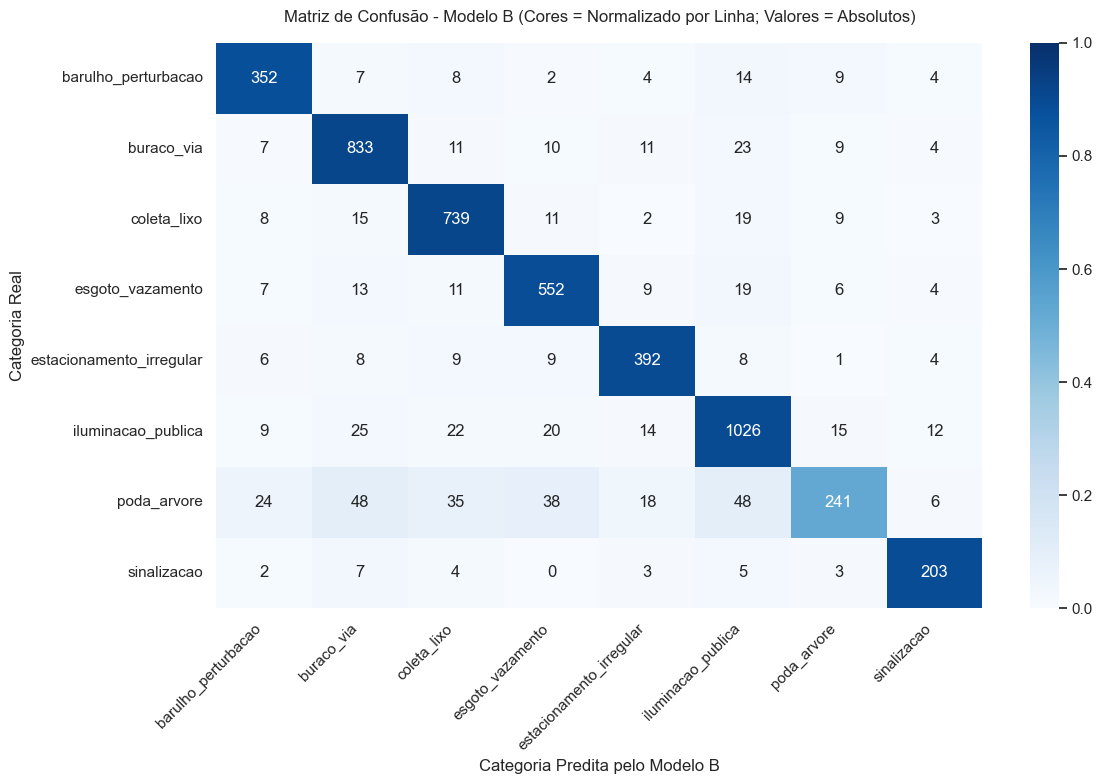

In [5]:
from sklearn.metrics import confusion_matrix

# Matriz de Confusão do Modelo B
categorias = sorted(list(set(y_true)))
cm_b = confusion_matrix(y_true, y_pred_b, labels=categorias)
cm_b_normalized = cm_b.astype('float') / cm_b.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 8))
ax = sns.heatmap(
    cm_b_normalized, 
    annot=cm_b, 
    fmt='d', 
    cmap='Blues',
    xticklabels=categorias, 
    yticklabels=categorias,
    vmin=0, vmax=1
)

plt.title('Matriz de Confusão - Modelo B (Cores = Normalizado por Linha; Valores = Absolutos)', pad=15)
plt.ylabel('Categoria Real')
plt.xlabel('Categoria Predita pelo Modelo B')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Resultados

A inspeção visual da matriz do Modelo B confirma a resolução da falha logística crítica: a sobreposição entre `esgoto_vazamento` e `buraco_via` foi virtualmente eliminada. Os falsos negativos de `poda_arvore` (o trade-off identificado no Passo 3) não se concentram em uma única categoria incorreta, mas variam pelo painel, sugerindo uma dificuldade semântica isolada do modelo com termos de arborização, sem outro novo gargalo.

---

## Passo 5: Auditoria de Calibração e Incerteza (Modelo B)

Outro teste técnico importante antes da recomendação executiva avalia o risco de automação. Na Fase 2, descobrimos que o Modelo A era severamente "superconfiante", onde ele errava com o mesmo grau de certeza matemática com que acertava, inviabilizando o roteamento automático de chamados.

Nesta etapa, replicamos o cálculo do **Expected Calibration Error (ECE)** e o diagrama de densidade de confiança para o Modelo B. O objetivo é responder se o Modelo B sabe quando está confuso.

=== Expected Calibration Error (ECE) - Modelo B ===: 0.1195


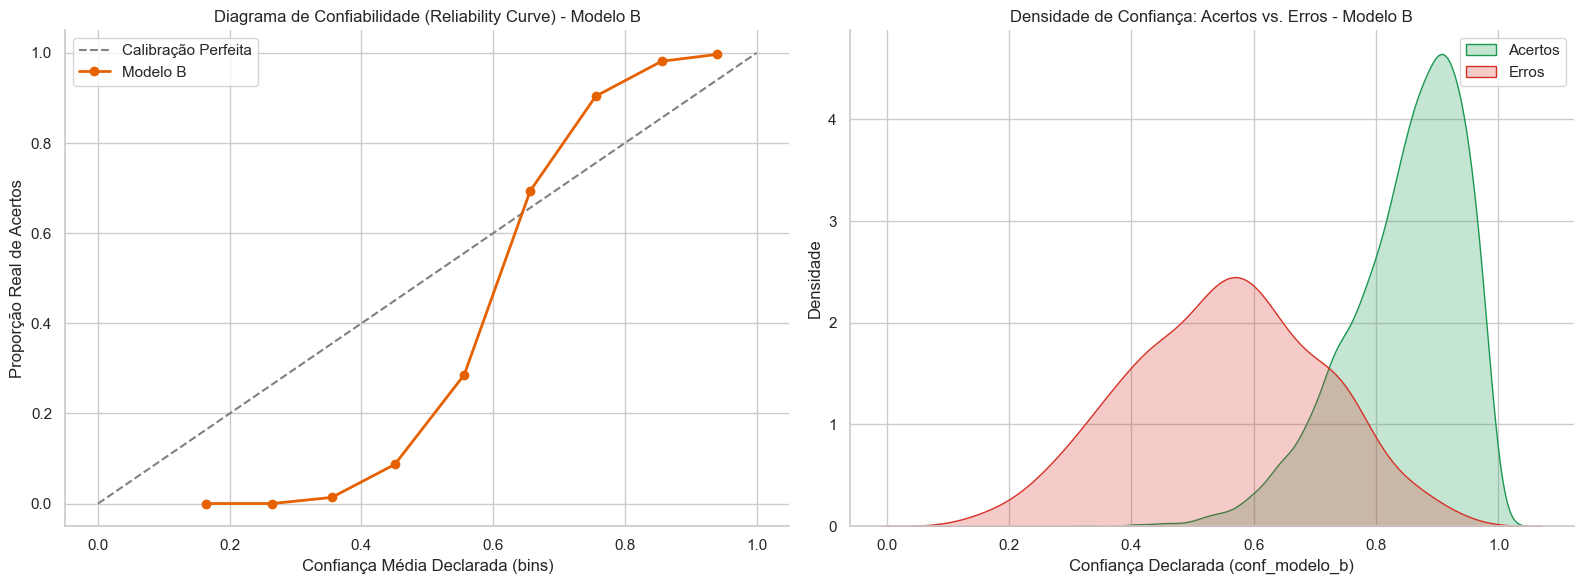

In [6]:
from sklearn.calibration import calibration_curve

# Acertos vs Confiança do Modelo B
acertos_b = (y_true == y_pred_b).astype(int)
confianca_b = df['conf_modelo_b'].values

# Curva de Calibração e ECE
n_bins = 10
prob_verdadeira_b, prob_prevista_b = calibration_curve(acertos_b, confianca_b, n_bins=n_bins, strategy='uniform')

ece_b = 0
total_samples = len(confianca_b)
bin_edges = np.linspace(0, 1, n_bins + 1)

for i in range(n_bins):
    if i == n_bins - 1:
        bin_mask = (confianca_b >= bin_edges[i]) & (confianca_b <= bin_edges[i+1])
    else:
        bin_mask = (confianca_b >= bin_edges[i]) & (confianca_b < bin_edges[i+1])
    
    bin_samples = bin_mask.sum()
    if bin_samples > 0:
        bin_acc = acertos_b[bin_mask].mean()
        bin_conf = confianca_b[bin_mask].mean()
        ece_b += (bin_samples / total_samples) * np.abs(bin_acc - bin_conf)

print(f"=== Expected Calibration Error (ECE) - Modelo B ===: {ece_b:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diagrama de Confiabilidade
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração Perfeita')
axes[0].plot(prob_prevista_b, prob_verdadeira_b, marker='o', linewidth=2, color='#e66101', label='Modelo B')
axes[0].set_title('Diagrama de Confiabilidade (Reliability Curve) - Modelo B')
axes[0].set_xlabel('Confiança Média Declarada (bins)')
axes[0].set_ylabel('Proporção Real de Acertos')
axes[0].legend()

# Distribuição de Confiança - Acertos vs Erros
sns.kdeplot(confianca_b[acertos_b == 1], ax=axes[1], fill=True, color='#1a9850', label='Acertos')
sns.kdeplot(confianca_b[acertos_b == 0], ax=axes[1], fill=True, color='#d73027', label='Erros')
axes[1].set_title('Densidade de Confiança: Acertos vs. Erros - Modelo B')
axes[1].set_xlabel('Confiança Declarada (conf_modelo_b)')
axes[1].set_ylabel('Densidade')
axes[1].legend()

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

#### Resultados

A análise aprofundada revela a superioridade do Modelo B até na calibração: 

* A queda do Expected Calibration Error (ECE) global de 0.1516 (Modelo A) para 0.1195 (Modelo B) representa uma evolução para a governança da Central 1746. No modelo anterior, a sobreposição das curvas de densidade inviabilizava qualquer estratégia de automação baseada em criticidade, pois o algoritmo errava apresentando o mesmo nível de certeza matemática com que acertava. Com o Modelo B, a separação entre as distribuições de acertos e erros faz com que as predições incorretas se concentrem em faixas inferiores de probabilidade calculada.
* Essa distinção estatística viabiliza a implementação de uma esteira segura de triagem automatizada com lógica de supervisão humana (human-in-the-loop). Ao estabelecer um ponto de corte operacional (ex: 80% de confiança), todos os chamados abaixo desse limiar podem ser desviados automaticamente para auditoria manual. Essa regra de corte permite reter e corrigir a grande maioria dos erros antes que eles gerem despachos incorretos para as secretarias, enquanto os casos maiores esse limiar seguem para processamento automatizado, otimizando o tempo dos atendentes e evitando o transbordo de chamados corretos para a análise humana.

---

### 5.2. Teste Qui-Quadrado

Agora, por fim, analisamos novamente qual a relevância de cada feature para o resultado final, e checamos se ainda temos resultados homogênios quando analisados diferentes canais e bairros (onde data já cremos não relevante)

In [7]:
from scipy.stats import chi2_contingency

# Binarização do Erro para os Modelos A e B
df['errou'] = (df['categoria_real'] != df['pred_modelo_a']).astype(int)
df['errou_b'] = (df['categoria_real'] != df['pred_modelo_b']).astype(int)

if 'tamanho_texto_quartil' not in df.columns:
    df['tamanho_texto_quartil'] = pd.qcut(
        df['texto'].apply(lambda x: len(str(x).split())), 
        q=4, 
        labels=['Q1 (Mais curtos)', 'Q2', 'Q3', 'Q4 (Mais longos)']
    )

features_analise_b = {
    'canal': 'Canal de Entrada', 
    'tamanho_texto_quartil': 'Tamanho do Texto (Quartis)', 
    'bairro': 'Bairro'
}

# Teste de Independência de Erros (Modelo B)
resultados_homogeneidade_b = []

for feat, label in features_analise_b.items():
    tabela_b = pd.crosstab(df[feat], df['errou_b'])
    chi2, p_val, dof, ex = chi2_contingency(tabela_b)
    
    resultados_homogeneidade_b.append({
        'Subgrupo': label,
        'p-valor': p_val,
        'Desempenho Homogêneo?': 'Sim' if p_val >= 0.05 else 'Não (Modelo Enviesado)'
    })

print("=== Teste de Independência de Erros - Modelo B (Qui-Quadrado) ===")
display(pd.DataFrame(resultados_homogeneidade_b).set_index('Subgrupo'))

# Taxa de Erro: Modelo A vs Modelo B nos Textos Curtos (Q1)
erro_q1_a = df[df['tamanho_texto_quartil'] == 'Q1 (Mais curtos)']['errou'].mean() * 100
erro_q1_b = df[df['tamanho_texto_quartil'] == 'Q1 (Mais curtos)']['errou_b'].mean() * 100

print(f"\nTaxa de erro em textos curtos (Q1) - Modelo A: {erro_q1_a:.1f}%")
print(f"Taxa de erro em textos curtos (Q1) - Modelo B: {erro_q1_b:.1f}%")

=== Teste de Independência de Erros - Modelo B (Qui-Quadrado) ===


,p-valor,Desempenho Homogêneo?
Subgrupo,,
Canal de Entrada,0.241937,Sim
Tamanho do Texto (Quartis),0.069686,Sim
Bairro,0.455684,Sim



Taxa de erro em textos curtos (Q1) - Modelo A: 40.4%
Taxa de erro em textos curtos (Q1) - Modelo B: 14.5%


#### Resultados finais

Essa bateria final de testes estatísticos confirmaram a robustez do Modelo B e afastaram os riscos operacionais de sua implementação:

1. **Evolução na Calibração (Segurança de Automação):** O Modelo B obteve um *Expected Calibration Error* (ECE) de 0.1195, menor que o Modelo A, como já discutido.
2. **Resolução do Déficit de Contexto (Textos Curtos):** A falha do Modelo A na interpretação de textos curtos (Q1) foi diminuida. A taxa de erro despencou de 40.4% para 14.5%. O p-valor de 0.069 confirma, com 95% de confiança, que o desempenho do Modelo B agora é estatisticamente homogêneo, independentemente do número de palavras do texto da chamada.
3. **Equidade Operacional Mantida:** Testes de independência confirmam que a otimização matemática não introduziu vieses sistêmicos. O algoritmo segue imparcial em relação à geografia do chamado (Bairro, p-valor = 0.45) e ao meio tecnológico utilizado (Canal, p-valor = 0.24).

---

## Passo 6: Recomendação Executiva (Veredicto)

**Recomendação:** Devemos substituir o Modelo A pelo Modelo B na operação da Central 1746.

**Justificativa e Ganhos:**
A adoção do Modelo B entrega um salto de desempenho global estatisticamente comprovado. Do ponto de vista logístico, o principal ganho estrutural é a eliminação do gargalo entre problemas de saneamento (`esgoto_vazamento`) e pavimentação (`buraco_via`), cessando o roteamento incorreto de chamados de água para a Secretaria de Conservação e evitando o deslocamento inútil de maquinário. Além disso, a melhor calibração do modelo permite a adoção de uma esteira de automação segura (*human-in-the-loop*): ao estabelecer um limiar de confiança, o sistema despacha automaticamente a maioria dos chamados com alta precisão e desvia apenas as predições incertas para a triagem humana, otimizando o tempo dos atendentes e reduzindo custos operacionais.

**Riscos e Medidas de Mitigação (Trade-offs):**
A troca de arquitetura apresenta um único custo operacional mapeado: a degradação preditiva na categoria `poda_arvore`, que sofreu uma queda de 14.7 pontos em seu F1-Score. Diferente das falhas do Modelo A (que eram focadas em uma única classe), os erros de poda no Modelo B encontram-se pulverizados por todas as demais categorias, indicando que o novo algoritmo perdeu sensibilidade nos limites desta classe para privilegiar o ganho global.
* **Mitigação Recomendada (Guardrail Híbrido):** Como a análise lexical da Fase 1 provou que `poda_arvore` possui termos de altíssima especificidade e exclusividade ("poda", "árvore", "galho"), sugere-se a criação de um filtro sistêmico pós-predição. Qualquer chamado que contenha essas palavras-chave no texto, mas que receba do Modelo B uma classificação para outra secretaria com confiança inferior a 80%, deve ter seu despacho automatizado bloqueado e ser desviado para triagem humana.